This code is designed for data collect from Nikon JOBS, name the sample as "Rep_D6_087.nd2", have 3 channel, DAPI, GFP, Dsred in z stacks.

In [1]:
# =============================================================================
# Cell 1: Import Libraries and Check CUDA Availability
# =============================================================================
import os
import re
import gc
import torch
import numpy as np
import tifffile
import pandas as pd
from nd2reader import ND2Reader
from tqdm import tqdm
from cellpose import models

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU Name: {gpu_name}")
else:
    print("No GPU detected or CUDA is not available.")

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4090


In [2]:
# check the iamge file for example
import os
from nd2reader import ND2Reader

def check_nd2_info(nd2_path):
    """
    Opens an ND2 file and prints image information including:
      - Detected axes
      - Image dimensions (shape)
      - Channel names (if available)
      - Additional metadata
    """
    try:
        with ND2Reader(nd2_path) as img:
            print(f"\nProcessing ND2 File: {os.path.basename(nd2_path)}")
            print("Detected Axes:", img.axes)
            print("Image Shape:", img.shape)
            
            channels = img.metadata.get('channels')
            if channels:
                print("Channels:", channels)
            else:
                print("No channel information available in metadata.")
            
            # Print additional metadata keys and values
            print("Additional Metadata:")
            for key, value in img.metadata.items():
                print(f"  {key}: {value}")
    except Exception as e:
        print(f"Error processing {nd2_path}: {e}")

# Specify the ND2 file you want to inspect
nd2_file_path = r"A:\_Ongoing\20250329_Rep\Act_A1_001.nd2"
check_nd2_info(nd2_file_path)



Processing ND2 File: Act_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Image Shape: (7, 900, 600)
Channels: ['40x 405', '40x 561', '40x 488']
Additional Metadata:
  height: 900
  width: 600
  date: 2025-03-31 09:22:21
  fields_of_view: [0]
  frames: [0]
  z_levels: range(0, 7)
  z_coordinates: [4914.220000000008, 4914.840000000008, 4915.420000000008, 4916.040000000008, 4916.600000000009, 4917.240000000008, 4917.840000000008]
  total_images_per_channel: 7
  channels: ['40x 405', '40x 561', '40x 488']
  pixel_microns: 0.273400847258364
  num_frames: 1
  experiment: {'description': '', 'loops': []}
  events: []


In [3]:
# =============================================================================
# Configuration: Define Channel Names (Edit these if channel names change)
# =============================================================================
CHANNEL_DAPI  = '40x 405'   # Used for cell mask generation
CHANNEL_DsRed = '40x 561'
CHANNEL_GFP   = '40x 488'

In [58]:
# =============================================================================
# Function: Convert ND2 to TIFF for a Given Channel
# =============================================================================
def convert_nd2_to_tiff_channel(nd2_path, tiff_output_dir, channel_name):
    """
    Converts an ND2 file to TIFF files by performing a maximum intensity projection
    over the z-axis for the specified channel.
    
    Parameters:
      nd2_path: Path to the input ND2 file.
      tiff_output_dir: Directory where the TIFF files will be saved.
      channel_name: Name of the channel to extract.
    """
    try:
        with ND2Reader(nd2_path) as img:
            print(f"\nProcessing ND2 file: {os.path.basename(nd2_path)}")
            print("Detected Axes:", img.axes)
            print("Detected Shape:", img.shape)
            
            channels = img.metadata.get('channels')
            if channels is None:
                raise ValueError("No channel information found in ND2 metadata.")
            print("Channels in file:", channels)
            
            if channel_name in channels:
                channel_index = channels.index(channel_name)
                print(f"Using channel '{channel_name}' at index {channel_index}.")
            else:
                print(f"Channel '{channel_name}' not found in {nd2_path}. Skipping conversion for this channel.")
                return
            
            img.default_coords['c'] = channel_index

            # Setup iteration: if a time axis exists, iterate over it and bundle z,y,x.
            if 't' in img.axes and img.sizes.get('t', 1) > 1:
                img.iter_axes = 't'
                img.bundle_axes = 'zyx'
            else:
                img.iter_axes = ''
                img.bundle_axes = 'zyx'
                
            # For each time frame (or single image), perform a max projection along z.
            for idx, frame in enumerate(img):
                max_proj = np.max(frame, axis=0)
                base_name = os.path.splitext(os.path.basename(nd2_path))[0]
                if 't' in img.axes and img.sizes.get('t', 1) > 1:
                    tiff_filename = f"{base_name}_t{idx}.tiff"
                else:
                    tiff_filename = f"{base_name}.tiff"
                tiff_path = os.path.join(tiff_output_dir, tiff_filename)
                tifffile.imwrite(tiff_path, max_proj)
                print(f"Saved TIFF: {tiff_path}")
    except Exception as e:
        print(f"Error converting {nd2_path} for channel {channel_name} to TIFF: {e}")

# =============================================================================
# Function: Generate Cell Mask Using Cellpose (Using DAPI Channel)
# =============================================================================
def generate_cellmask(tiff_path, mask_path, model):
    """
    Generates a cell mask from the given TIFF image (typically DAPI) using Cellpose and saves the mask.
    
    Parameters:
      tiff_path: Path to the TIFF image used for mask generation.
      mask_path: Output path for the generated mask TIFF.
      model: An instance of the Cellpose model.
    """
    try:
        img = tifffile.imread(tiff_path)
        # If the image is 3D (a stack), average over the first axis to obtain a 2D image.
        if img.ndim == 3:
            img = img.mean(axis=0)
        elif img.ndim > 3:
            raise ValueError(f"Unexpected number of dimensions ({img.ndim}) in image: {tiff_path}")

        img_min, img_max = np.min(img), np.max(img)
        dynamic_range = img_max - img_min
        if dynamic_range == 0:
            print(f"Warning: Image {tiff_path} has zero dynamic range. Skipping mask generation.")
            return
        
        img = img.astype(np.float32)
        img = (img - img_min) / dynamic_range

        if not np.isfinite(img).all():
            print(f"Warning: Image {tiff_path} contains non-finite values after normalization. Skipping.")
            return

        # Run Cellpose (adjust parameters such as diameter if needed)
        masks, flows, styles, diams = model.eval(
            img,
            diameter=100,
            flow_threshold=0.4,
            cellprob_threshold=0.0,
            channels=[0, 0]
        )
        tifffile.imwrite(mask_path, masks.astype(np.uint16))
        print(f"Saved cell mask: {mask_path}")
    except Exception as e:
        print(f"Error generating mask for {tiff_path}: {e}")
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# =============================================================================
# Function: Calculate Cell-Level Intensities
# =============================================================================
def calculate_intensities(tiff_files, tiff_dirs, mask_dir, output_csv):
    """
    For each TIFF file, calculates the average intensity per cell (using the generated mask)
    for both GFP and DsRed channels and saves the data to a CSV file.
    
    Parameters:
      tiff_files: List of TIFF filenames (assumed to be identical for GFP and DsRed channels).
      tiff_dirs: Dictionary with keys "GFP" and "DsRed" mapping to their respective TIFF directories.
      mask_dir: Directory where the cell masks are stored.
      output_csv: Path for the output CSV file.
    """
    data = []
    for tiff_file in tqdm(tiff_files, desc="Calculating Intensities"):
        gfp_path = os.path.join(tiff_dirs["GFP"], tiff_file)
        dsred_path = os.path.join(tiff_dirs["DsRed"], tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        if not os.path.exists(gfp_path):
            print(f"GFP image {gfp_path} not found. Skipping.")
            continue
        if not os.path.exists(dsred_path):
            print(f"DsRed image {dsred_path} not found. Skipping.")
            continue
        if not os.path.exists(mask_path):
            print(f"Mask image {mask_path} not found. Skipping.")
            continue
        
        gfp_img = tifffile.imread(gfp_path)
        dsred_img = tifffile.imread(dsred_path)
        mask_img = tifffile.imread(mask_path)
        
        mask_indices = np.unique(mask_img)
        mask_indices = mask_indices[mask_indices != 0]  # Exclude background
        
        for idx in mask_indices:
            cell_mask = (mask_img == idx)
            avg_gfp = np.mean(gfp_img[cell_mask])
            avg_dsred = np.mean(dsred_img[cell_mask])
            data.append({
                "File Name": tiff_file,
                "Mask Index": idx,
                "Average GFP Intensity": avg_gfp,
                "Average DsRed Intensity": avg_dsred
            })
    
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"Cell-level intensity data saved to {output_csv}")

# =============================================================================
# Helper Function: Extract Group, Sample, and Repeat Information
# =============================================================================
def extract_info_from_filename(filename):
    """
    Extracts group (Act/Rep), sample, and repeat information from the filename.
    It first removes any time suffix (e.g., _t0) if present.
    
    Expected filename formats include:
      - 'Act_01_002.nd2'
      - 'Rep_A1_001.nd2'
    """
    base = re.sub(r'_t\d+', '', os.path.splitext(filename)[0])
    pattern = re.compile(r'^(Act|Rep)_([A-Za-z0-9]+)_(\d{3})', re.IGNORECASE)
    m = pattern.search(base)
    if m:
        return m.group(1), m.group(2), m.group(3)
    else:
        return 'Unknown', 'Unknown', 'Unknown'

# =============================================================================
# Runnable Step 1: ND2-to-TIFF Conversion for Each Channel
# =============================================================================
def run_conversion(nd2_dir, dapi_tiff_dir, dsred_tiff_dir, gfp_tiff_dir):
    """
    Converts all ND2 files in the given directory into TIFF images for the DAPI, DsRed, and GFP channels.
    
    Parameters:
      nd2_dir: Directory containing ND2 files.
      dapi_tiff_dir: Output directory for the DAPI TIFF images.
      dsred_tiff_dir: Output directory for the DsRed TIFF images.
      gfp_tiff_dir: Output directory for the GFP TIFF images.
    """
    nd2_files = [f for f in os.listdir(nd2_dir) if f.lower().endswith('.nd2')]
    if not nd2_files:
        print("No ND2 files found in", nd2_dir)
        return
    print(f"Found {len(nd2_files)} ND2 file(s) for conversion.")
    for nd2_file in nd2_files:
        nd2_path = os.path.join(nd2_dir, nd2_file)
        print(f"\n--- Processing: {nd2_file} ---")
        # Convert DAPI channel (for cell mask generation)
        convert_nd2_to_tiff_channel(nd2_path, dapi_tiff_dir, CHANNEL_DAPI)
        # Convert DsRed and GFP channels (for intensity analysis)
        convert_nd2_to_tiff_channel(nd2_path, dsred_tiff_dir, CHANNEL_DsRed)
        convert_nd2_to_tiff_channel(nd2_path, gfp_tiff_dir, CHANNEL_GFP)

# code to analysis

In [ ]:
# =============================================================================
# Set Up Directories and Run Conversion
# =============================================================================
nd2_dir       = r"A:\_Ongoing\20250329_Rep"
output_dir    = os.path.join(nd2_dir, "Output")
dapi_tiff_dir = os.path.join(output_dir, "DAPI_TIFF")
dsred_tiff_dir= os.path.join(output_dir, "DsRed_TIFF")
gfp_tiff_dir  = os.path.join(output_dir, "GFP_TIFF")
mask_dir      = os.path.join(output_dir, "mask_100")

# Create output directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(dapi_tiff_dir, exist_ok=True)
os.makedirs(dsred_tiff_dir, exist_ok=True)
os.makedirs(gfp_tiff_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# Run ND2-to-TIFF conversion
run_conversion(nd2_dir, dapi_tiff_dir, dsred_tiff_dir, gfp_tiff_dir)

Found 3600 ND2 file(s) for conversion.

--- Processing: Act_A1_001.nd2 ---

Processing ND2 file: Act_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 405' at index 0.
Saved TIFF: A:\_Ongoing\20250329_Rep\Output\DAPI_TIFF\Act_A1_001.tiff

Processing ND2 file: Act_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 561' at index 1.
Saved TIFF: A:\_Ongoing\20250329_Rep\Output\DsRed_TIFF\Act_A1_001.tiff

Processing ND2 file: Act_A1_001.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shape: (7, 900, 600)
Channels in file: ['40x 405', '40x 561', '40x 488']
Using channel '40x 488' at index 2.
Saved TIFF: A:\_Ongoing\20250329_Rep\Output\GFP_TIFF\Act_A1_001.tiff

--- Processing: Act_A1_002.nd2 ---

Processing ND2 file: Act_A1_002.nd2
Detected Axes: ['x', 'y', 'c', 't', 'z']
Detected Shap

In [ ]:
# =============================================================================
# Runnable Step 2: Cell Mask Generation Using DAPI Channel
# =============================================================================
def run_mask_generation(dapi_tiff_dir, mask_dir, model):
    """
    Generates cell masks from DAPI channel TIFF images using Cellpose.
    
    Parameters:
      dapi_tiff_dir: Directory containing DAPI TIFF images (for cell mask generation).
      mask_dir: Directory where the generated mask images will be saved.
      model: An initialized Cellpose model.
    """
    # Filter out TIFF files that are not masks already
    dapi_tiff_files = [f for f in os.listdir(dapi_tiff_dir)
                       if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not dapi_tiff_files:
        print("No DAPI TIFF files found in", dapi_tiff_dir)
        return
    
    print(f"Generating cell masks for {len(dapi_tiff_files)} DAPI TIFF file(s)...")
    for tiff_file in tqdm(dapi_tiff_files, desc="Generating Masks"):
        tiff_path = os.path.join(dapi_tiff_dir, tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        generate_cellmask(tiff_path, mask_path, model)
    
    print("Cell mask generation completed.")

# =============================================================================
# Initialize the Cellpose Model and Run Mask Generation
# =============================================================================
print("\n=== Cell Mask Generation ===")
try:
    model = models.Cellpose(gpu=torch.cuda.is_available(), model_type="cyto3")
    print("Cellpose model initialized.")
except Exception as e:
    print("Error initializing Cellpose model:", e)
    print("Falling back to CPU mode with cyto2.")
    model = models.Cellpose(gpu=False, model_type="cyto2")

# Run mask generation using the DAPI channel TIFF images
run_mask_generation(dapi_tiff_dir, mask_dir, model)



=== Cell Mask Generation ===
Cellpose model initialized.
Generating cell masks for 3600 DAPI TIFF file(s)...


Generating Masks:   0%|          | 1/3600 [00:00<53:11,  1.13it/s]

Saved cell mask: A:\_Ongoing\20250329_Rep\Output\mask_none\Act_A1_001_mask.tiff


Generating Masks:   0%|          | 2/3600 [00:01<41:42,  1.44it/s]

Saved cell mask: A:\_Ongoing\20250329_Rep\Output\mask_none\Act_A1_002_mask.tiff


...

Saved cell mask: A:\_Ongoing\20250329_Rep\Output\mask_none\Act_A1_038_mask.tiff


Generating Masks:   1%|          | 39/3600 [00:24<38:16,  1.55it/s]

Saved cell mask: A:\_Ongoing\20250329_Rep\Output\mask_none\Act_A1_039_mask.tiff


Generating Masks:   1%|          | 39/3600 [00:25<38:36,  1.54it/s]


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# Filter out small or too long mask
# =============================================================================
import os
import numpy as np
import tifffile
from skimage.measure import regionprops
from tqdm import tqdm

# -----------------------------
# SET UP DIRECTORIES
# -----------------------------
output_dir = os.path.join(nd2_dir, "Output")
mask_dir = os.path.join(output_dir, "mask_100")  # Original mask folder
new_mask_dir = os.path.join(output_dir, "mask_filtered")  # New folder for filtered masks
os.makedirs(new_mask_dir, exist_ok=True)

# -----------------------------
# FILTER PARAMETERS
# -----------------------------
size_threshold = 2000      # Remove objects with area < 1500 pixels
length_threshold = 180     # Remove objects with major axis length > 180

# -----------------------------
# PROCESS EACH MASK FILE
# -----------------------------
mask_files = [f for f in os.listdir(mask_dir) if f.lower().endswith(('.tif', '.tiff'))]

for mask_file in tqdm(mask_files, desc="Filtering masks"):
    mask_path = os.path.join(mask_dir, mask_file)
    new_mask_path = os.path.join(new_mask_dir, mask_file)
    try:
        # Read the mask image
        mask_img = tifffile.imread(mask_path)
        
        # Create a copy for filtering
        filtered_mask = mask_img.copy()
        
        # Compute properties of each object in the mask
        for region in regionprops(mask_img):
            # Filter out objects that are too small or too elongated
            if region.area < size_threshold or region.major_axis_length > length_threshold:
                filtered_mask[mask_img == region.label] = 0
        
        # Save the filtered mask
        tifffile.imwrite(new_mask_path, filtered_mask.astype(np.uint16))
        print(f"Saved filtered mask: {new_mask_path}")
        
    except Exception as e:
        print(f"Error processing {mask_file}: {e}")


Filtering masks:   0%|          | 13/3600 [00:00<00:29, 122.46it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_001_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_002_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_003_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_004_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_005_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_006_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_007_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_008_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_009_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_010_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_011_mask.tiff
Saved filtered mask: A:\_Ongoing

Filtering masks:   1%|          | 39/3600 [00:00<00:29, 120.04it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_026_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_027_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_028_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_029_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_030_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_031_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_032_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_033_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_034_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_035_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Act_A1_036_mask.tiff
Saved filtered mask: A:\_Ongoing

Filtering masks:   2%|▏         | 65/3600 [00:00<00:29, 118.68it/s]

...

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_029_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_030_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_031_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_032_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_033_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_034_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_035_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_036_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_037_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_038_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_039_mask.tiff
Saved filtered mask: A:\_Ongoing

Filtering masks: 100%|█████████▉| 3586/3600 [00:30<00:00, 85.82it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_049_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_050_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_051_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_052_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_053_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_054_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_055_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_056_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_057_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_058_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_059_mask.tiff
Saved filtered mask: A:\_Ongoing

Filtering masks: 100%|██████████| 3600/3600 [00:31<00:00, 115.95it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_065_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_066_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_067_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_068_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_069_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_070_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_071_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_072_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_073_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_074_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered\Rep_D6_075_mask.tiff


# cellpose checing visulize

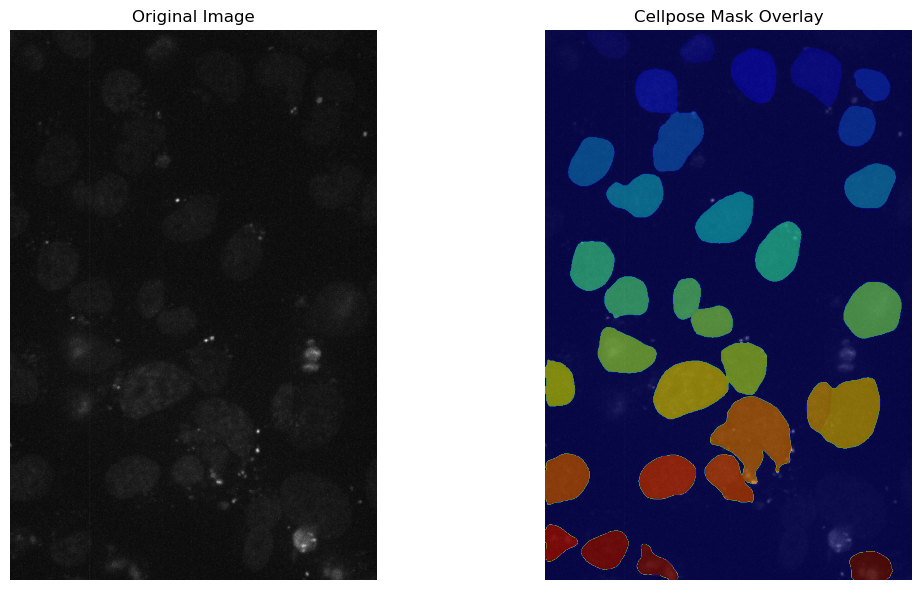

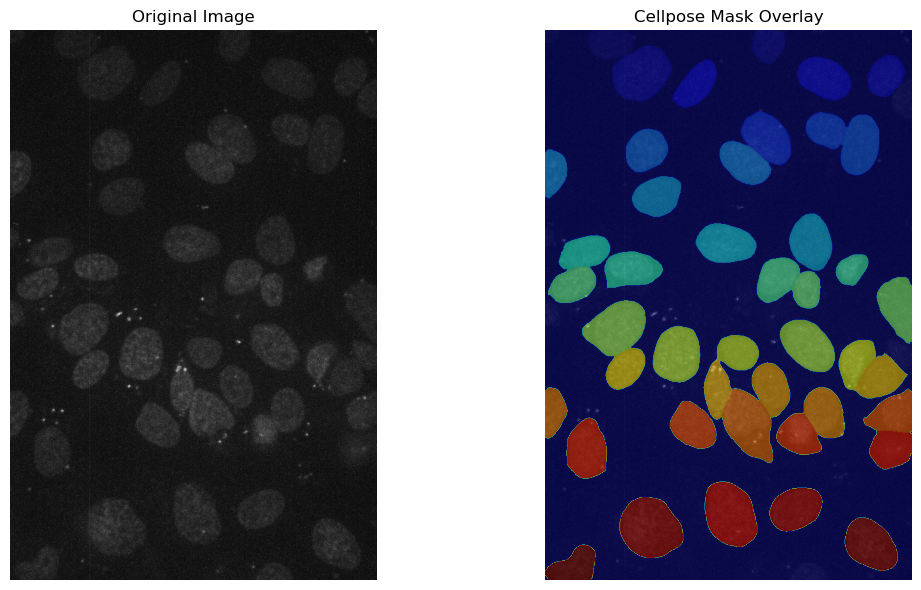

In [19]:
import random
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(image_dir, mask_dir, num_samples=5, seed=None):
    """
    Randomly selects and visualizes TIFF images with their corresponding Cellpose masks.
    
    Parameters:
      image_dir (str): Directory containing the original TIFF images (e.g., DAPI images used for mask generation).
      mask_dir (str): Directory containing the Cellpose mask TIFFs.
      num_samples (int): Number of random samples to visualize.
      seed (int, optional): Seed for reproducibility.
    """
    # Set seed for reproducibility if provided
    if seed is not None:
        random.seed(seed)
    
    # Get list of TIFF files (exclude mask files)
    image_files = [f for f in os.listdir(image_dir) 
                   if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not image_files:
        print(f"No TIFF files found in {image_dir}.")
        return
    
    # Adjust number of samples if there are fewer files than requested
    num_samples = min(num_samples, len(image_files))
    samples = random.sample(image_files, num_samples)
    
    for img_file in samples:
        img_path = os.path.join(image_dir, img_file)
        mask_filename = os.path.splitext(img_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Check if the corresponding mask file exists
        if not os.path.exists(mask_path):
            print(f"Mask file {mask_filename} does not exist. Skipping {img_file}.")
            continue
        
        try:
            img = tifffile.imread(img_path)
            mask = tifffile.imread(mask_path)
            
            # If the image has multiple channels, average them to get a grayscale representation
            if img.ndim == 3:
                img_display = img.mean(axis=0)
            else:
                img_display = img
            
            # Normalize the image for display purposes
            img_display = img_display.astype(np.float32)
            img_display -= img_display.min()
            if img_display.max() != 0:
                img_display /= img_display.max()
            
            plt.figure(figsize=(12, 6))
            
            # Display the original image
            plt.subplot(1, 2, 1)
            plt.imshow(img_display, cmap='gray')
            plt.title('Original Image')
            plt.axis('off')
            
            # Display the mask overlay on the original image
            plt.subplot(1, 2, 2)
            plt.imshow(img_display, cmap='gray')
            plt.imshow(mask, cmap='jet', alpha=0.5)  # Overlay mask with transparency
            plt.title('Cellpose Mask Overlay')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error visualizing {img_file}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Define the directories for DAPI images (used for mask generation) and the generated masks.
dapi_image_dir = dapi_tiff_dir
mask_output_dir = new_mask_dir

# Visualize random samples (e.g., 2 samples, with a seed for reproducibility)
visualize_random_samples(dapi_image_dir, mask_output_dir, num_samples=2, seed=33223)


# autosclae the tiff image for better screen show

In [52]:
import os
import numpy as np
import tifffile
from tqdm import tqdm

def autoscale_to_8bit(image, percentile=99):
    """
    Autoscale a 16-bit image to 8-bit using the 99th percentile as the maximum.
    
    Parameters:
      image (np.ndarray): The input image (assumed to be 16-bit).
      percentile (float): The percentile to use for the maximum intensity.
      
    Returns:
      np.ndarray: The rescaled 8-bit image.
    """
    # Compute the minimum and the desired maximum (99th percentile)
    img_min = np.min(image)
    img_p99 = np.percentile(image, percentile)
    
    # Prevent division by zero in case the image is flat
    if img_p99 - img_min == 0:
        scaled = np.zeros_like(image, dtype=np.uint8)
    else:
        # Scale intensities so that values below img_min map to 0 and
        # values at or above img_p99 are capped at 1 (then multiplied by 255).
        scaled = (image - img_min) / (img_p99 - img_min)
        # Clip values above 1 (if any) to 1.
        scaled[scaled > 1] = 1
        scaled = (scaled * 255).astype(np.uint8)
    return scaled

def regenerate_for_viewing(channel_dirs, output_forimage_dir, percentile=99):
    """
    Processes images from each channel directory by autoscaling them from 16-bit to 8-bit,
    using the given percentile as the maximum intensity. The processed images are saved
    in subdirectories under the output_forimage_dir.
    
    Parameters:
      channel_dirs (dict): Dictionary with keys as channel names (e.g., 'DAPI', 'GFP', 'DsRed')
                           and values as the directories containing the original 16-bit images.
      output_forimage_dir (str): Path to the output "forimage" folder.
      percentile (float): Percentile to use for scaling (default is 99).
    """
    # Create the output forimage directory if it doesn't exist.
    os.makedirs(output_forimage_dir, exist_ok=True)
    
    for channel, input_dir in channel_dirs.items():
        # Create a subfolder for the channel
        channel_out_dir = os.path.join(output_forimage_dir, channel)
        os.makedirs(channel_out_dir, exist_ok=True)
        
        # List TIFF files in the input directory (ignore any mask files)
        image_files = [f for f in os.listdir(input_dir)
                       if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
        
        for img_file in tqdm(image_files, desc=f"Processing {channel} images"):
            input_path = os.path.join(input_dir, img_file)
            output_path = os.path.join(channel_out_dir, img_file)
            try:
                img = tifffile.imread(input_path)
                
                # If the image is 3D (e.g., a z-stack), average over the first axis to obtain a 2D image.
                if img.ndim == 3:
                    img = img.mean(axis=0)
                
                # Apply autoscaling to 8-bit.
                scaled_img = autoscale_to_8bit(img, percentile)
                tifffile.imwrite(output_path, scaled_img)
            except Exception as e:
                print(f"Error processing {input_path}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Set your output directory (update this path as needed)
output_dir = r"A:\_Ongoing\20250329_Rep\Output"

# Create the forimage folder under the output directory
output_forimage_dir = os.path.join(output_dir, "forimage")

# Define the directories for each channel (these should be the original 16-bit images)
channel_dirs = {
    "DAPI": dapi_tiff_dir,    # Path to DAPI TIFF images (from your earlier code)
    "GFP": gfp_tiff_dir,      # Path to GFP TIFF images
    "DsRed": dsred_tiff_dir   # Path to DsRed TIFF images
}

# Regenerate the easier-to-view 8-bit images
regenerate_for_viewing(channel_dirs, output_forimage_dir, percentile=99)


Processing DsRed images: 100%|██████████| 3600/3600 [00:27<00:00, 132.15it/s]


# filter out dead cell (use DAPI channel and z-sore)

In [ ]:

import os
import numpy as np
import tifffile
from skimage.measure import regionprops
from tqdm import tqdm

def filter_dead_cells_by_dapi(mask_input_dir, dapi_dir, output_mask_dead_dir, z_thresh=3, fraction_thresh=0.1):
    """
    Filters out cell masks that likely represent dead cells based on uneven DAPI intensity.
    
    For each cell region in the mask, the function computes the mean and standard deviation of 
    the DAPI intensities within that region. It then calculates the fraction of pixels whose intensity 
    exceeds (mean + z_thresh * std). If this fraction is above fraction_thresh, the region is removed 
    from the mask.
    
    Parameters:
      mask_input_dir (str): Directory containing the input mask TIFF files (e.g., from previous filtering).
      dapi_dir (str): Directory containing the DAPI channel TIFF images.
      output_mask_dead_dir (str): Directory where the new masks with dead cells filtered out will be saved.
      z_thresh (float): Z-score threshold (default is 3).
      fraction_thresh (float): Fraction threshold for pixels exceeding the z-score threshold (default 0.1, i.e., 10%).
    """
    os.makedirs(output_mask_dead_dir, exist_ok=True)
    
    # List all mask files (TIFF files)
    mask_files = [f for f in os.listdir(mask_input_dir) if f.lower().endswith(('.tif', '.tiff'))]
    
    for mask_file in tqdm(mask_files, desc="Filtering dead cells by DAPI"):
        mask_path = os.path.join(mask_input_dir, mask_file)
        # Assume the corresponding DAPI image has the same base name (without '_mask')
        base_name = os.path.splitext(mask_file)[0].replace('_mask', '')
        dapi_filename = base_name + os.path.splitext(mask_file)[1]
        dapi_path = os.path.join(dapi_dir, dapi_filename)
        
        if not os.path.exists(dapi_path):
            print(f"DAPI image for {mask_file} not found in {dapi_dir}. Skipping.")
            continue
        
        try:
            mask_img = tifffile.imread(mask_path)
            dapi_img = tifffile.imread(dapi_path)
            
            # Copy the mask to modify it
            filtered_mask = mask_img.copy()
            
            # Compute properties for each region in the mask using the DAPI image as the intensity image.
            props = regionprops(mask_img, intensity_image=dapi_img)
            for region in props:
                # Get the intensity values from the DAPI channel for the current cell region.
                coords = region.coords
                cell_intensities = dapi_img[coords[:, 0], coords[:, 1]]
                if cell_intensities.size == 0:
                    continue
                mean_intensity = np.mean(cell_intensities)
                std_intensity = np.std(cell_intensities)
                # Define the threshold as mean + z_thresh * std.
                thresh_value = mean_intensity + z_thresh * std_intensity
                # Compute the fraction of pixels above this threshold.
                fraction = np.sum(cell_intensities > thresh_value) / cell_intensities.size
                
                # If the fraction exceeds the fraction threshold, remove the cell (set pixels to background).
                if fraction > fraction_thresh:
                    filtered_mask[mask_img == region.label] = 0
            
            # Save the new filtered mask.
            output_path = os.path.join(output_mask_dead_dir, mask_file)
            tifffile.imwrite(output_path, filtered_mask.astype(np.uint16))
            print(f"Saved filtered mask: {output_path}")
            
        except Exception as e:
            print(f"Error processing {mask_file}: {e}")

# =============================================================================
# Example Usage:
# =============================================================================
# Update these paths as needed.
output_dir = r"A:\_Ongoing\20250329_Rep\Output"
mask_input_dir = os.path.join(output_dir, "mask_filtered")      # Input masks (after initial filtering)
dapi_tiff_dir = os.path.join(output_dir, "DAPI_TIFF")             # DAPI channel images
output_mask_dead_dir = os.path.join(output_dir, "mask_filtered_zscore")  # New folder for final masks

# Run the filtering function with a z threshold of 3 and fraction threshold of 0.01 (1%).
filter_dead_cells_by_dapi(mask_input_dir, dapi_tiff_dir, output_mask_dead_dir, z_thresh=3, fraction_thresh=0.01)


Filtering dead cells by DAPI:   0%|          | 9/3600 [00:00<00:41, 87.16it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_001_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_002_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_003_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_004_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_005_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_006_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_007_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_008_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_009_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_010_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Outp

Filtering dead cells by DAPI:   1%|          | 31/3600 [00:00<00:35, 101.61it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_019_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_020_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_021_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_022_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_023_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_024_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_025_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_026_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_027_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Act_A1_028_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Outp

Filtering dead cells by DAPI:   2%|▏         | 65/3600 [00:00<00:33, 106.70it/s]

...

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_033_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_034_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_035_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_036_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_037_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_038_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_039_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_040_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_041_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_042_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Outp

Filtering dead cells by DAPI: 100%|█████████▉| 3588/3600 [00:31<00:00, 91.20it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_053_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_054_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_055_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_056_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_057_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_058_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_059_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_060_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_061_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_062_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Outp

Filtering dead cells by DAPI: 100%|██████████| 3600/3600 [00:31<00:00, 115.18it/s]

Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_071_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_072_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_073_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_074_mask.tiff
Saved filtered mask: A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore\Rep_D6_075_mask.tiff


# after autoscle, after dead cell filer, put all channel together

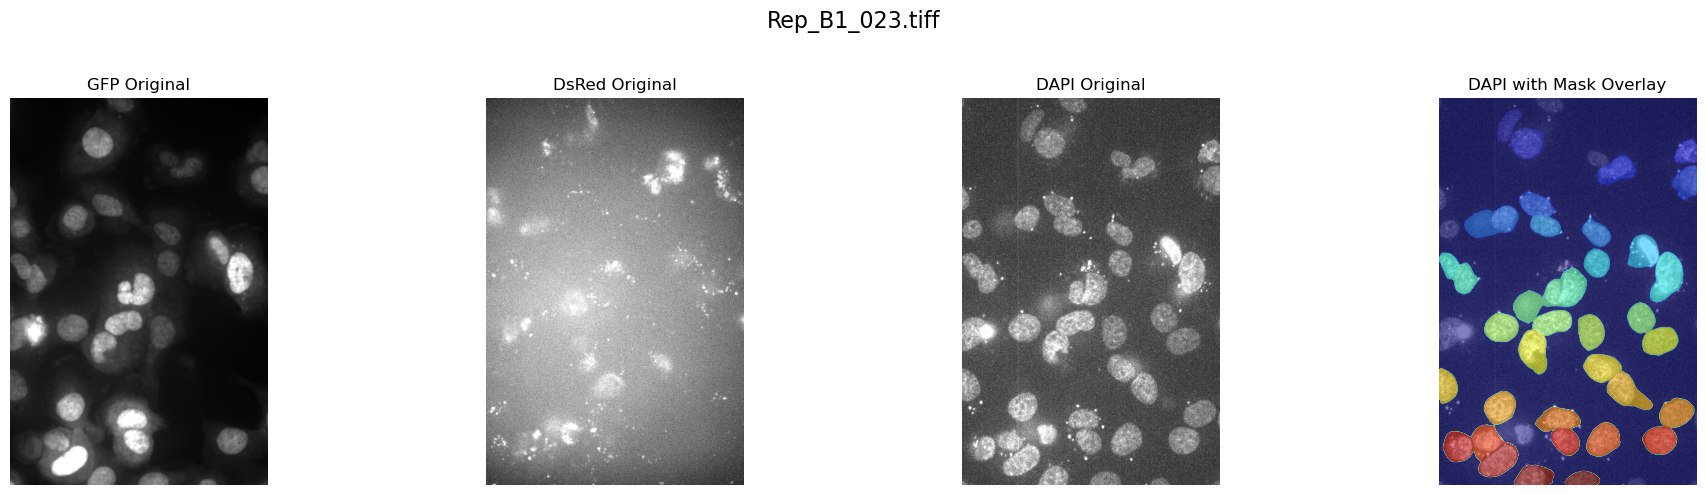

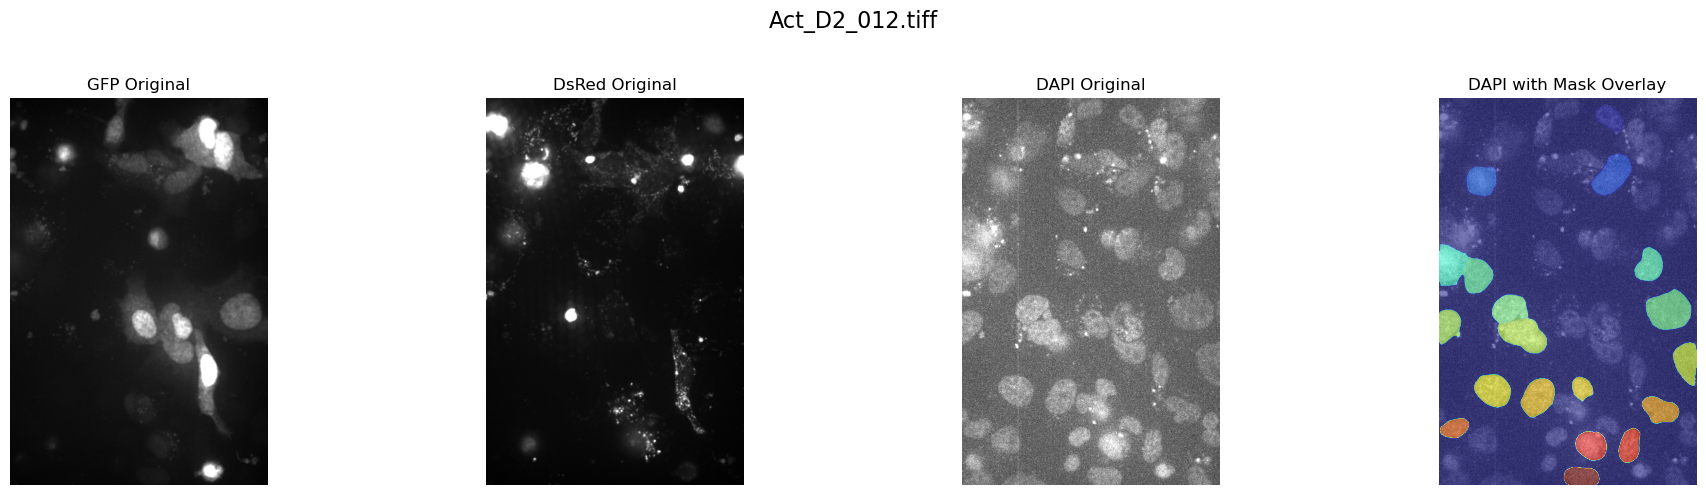

In [25]:
import random
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples_all_channels(gfp_dir, dsred_dir, dapi_dir, mask_dir, num_samples=5, seed=None):
    """
    Randomly selects and visualizes TIFF images for three channels along with a mask overlay.
    
    The layout is as follows (left to right):
      - GFP original
      - DsRed original
      - DAPI original
      - DAPI with mask overlay
    
    Parameters:
      gfp_dir (str): Directory containing the GFP channel TIFF images.
      dsred_dir (str): Directory containing the DsRed channel TIFF images.
      dapi_dir (str): Directory containing the DAPI channel TIFF images.
      mask_dir (str): Directory containing the DAPI mask TIFFs.
      num_samples (int): Number of random samples to visualize.
      seed (int, optional): Seed for reproducibility.
    """
    # Use the DAPI channel as reference for file names
    image_files = [f for f in os.listdir(dapi_dir) 
                   if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not image_files:
        print(f"No TIFF files found in {dapi_dir}.")
        return
    
    if seed is not None:
        random.seed(seed)
    num_samples = min(num_samples, len(image_files))
    samples = random.sample(image_files, num_samples)
    
    for img_file in samples:
        base_name = os.path.splitext(img_file)[0]
        mask_filename = base_name + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        if not os.path.exists(mask_path):
            print(f"Mask file {mask_filename} does not exist. Skipping {img_file}.")
            continue
        
        try:
            # Build file paths for each channel
            gfp_path = os.path.join(gfp_dir, img_file)
            dsred_path = os.path.join(dsred_dir, img_file)
            dapi_path = os.path.join(dapi_dir, img_file)
            
            # Check if all required files exist
            if not (os.path.exists(gfp_path) and os.path.exists(dsred_path) and os.path.exists(dapi_path)):
                print(f"One or more channel images missing for {img_file}. Skipping.")
                continue
            
            # Load images and mask
            gfp_img = tifffile.imread(gfp_path)
            dsred_img = tifffile.imread(dsred_path)
            dapi_img = tifffile.imread(dapi_path)
            mask = tifffile.imread(mask_path)
            
            # Function to normalize image for display
            def normalize_image(img):
                if img.ndim == 3:
                    img_disp = img.mean(axis=0)
                else:
                    img_disp = img
                img_disp = img_disp.astype(np.float32)
                img_disp -= img_disp.min()
                if img_disp.max() != 0:
                    img_disp /= img_disp.max()
                return img_disp
            
            gfp_disp = normalize_image(gfp_img)
            dsred_disp = normalize_image(dsred_img)
            dapi_disp = normalize_image(dapi_img)
            
            # Create a figure with 4 subplots
            plt.figure(figsize=(20, 5))
            plt.suptitle(img_file, fontsize=16)
            
            # Panel 1: GFP original
            ax1 = plt.subplot(1, 4, 1)
            ax1.imshow(gfp_disp, cmap='gray')
            ax1.set_title('GFP Original')
            ax1.axis('off')
            
            # Panel 2: DsRed original
            ax2 = plt.subplot(1, 4, 2)
            ax2.imshow(dsred_disp, cmap='gray')
            ax2.set_title('DsRed Original')
            ax2.axis('off')
            
            # Panel 3: DAPI original
            ax3 = plt.subplot(1, 4, 3)
            ax3.imshow(dapi_disp, cmap='gray')
            ax3.set_title('DAPI Original')
            ax3.axis('off')
            
            # Panel 4: DAPI with mask overlay
            ax4 = plt.subplot(1, 4, 4)
            ax4.imshow(dapi_disp, cmap='gray')
            ax4.imshow(mask, cmap='jet', alpha=0.5)  # Overlay the mask
            ax4.set_title('DAPI with Mask Overlay')
            ax4.axis('off')
            
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
            
        except Exception as e:
            print(f"Error visualizing {img_file}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Define directories for each channel (update these paths as needed)

gfp_tiff_dir = r"A:\_Ongoing\20250329_Rep\Output\forimage\GFP"
dsred_tiff_dir = r"A:\_Ongoing\20250329_Rep\Output\forimage\DsRed"
dapi_tiff_dir = r"A:\_Ongoing\20250329_Rep\Output\forimage\DAPI"
mask_output_dir = r"A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore"

# Visualize random samples (e.g., 2 samples, with a seed for reproducibility)
visualize_random_samples_all_channels(gfp_tiff_dir, dsred_tiff_dir, dapi_tiff_dir, mask_output_dir, num_samples=2, seed=333)



# collect the min intensity from each image and collect net instensity of GFP and DsRed (including area calculation)

In [29]:
import os
import numpy as np
import pandas as pd
import tifffile
from tqdm import tqdm

# =============================================================================
# Extraction Function for the Updated Naming Strategy
# =============================================================================
def extract_info_from_filename_new(filename):
    """
    Extracts group, sample code, and repeat information from a filename following the pattern:
      "Group_Sample_Repeat.ext"
    For example, "Act_A2_008.tiff" yields:
      Group: "Act"
      Sample: "A2"
      Repeat: "008"
    
    Returns:
      A tuple: (Group, Sample, Repeat)
    """
    base = os.path.splitext(filename)[0]
    parts = base.split('_')
    if len(parts) < 3:
        return "Unknown", "Unknown", "Unknown"
    group = parts[0]
    sample_code = parts[1]
    repeat = parts[2]
    return group, sample_code, repeat

# =============================================================================
# Sample Mapping Dictionary (New Naming Strategy)
# =============================================================================
sample_mapping = {
    "A1": "Tile 1",
    "A2": "Tile 2",
    "A3": "Tile 3",
    "A4": "Tile 4",
    "A5": "Tile 5",
    "A6": "Tile 6",
    "B1": "Tile 7",
    "B2": "Tile 8",
    "B3": "Tile 9",
    "B4": "Tile 10",
    "B5": "Tile 11",
    "B6": "Tile 12",
    "C1": "Tile 13",
    "C2": "Tile 14",
    "C3": "LAP*IDR",
    "C4": "LAPIDR",
    "C5": "LIPIDR",
    "C6": "FL",
    "D1": "optLAP*IDR",
    "D2": "old VP16",
    "D3": "old RUNX2CTD",
    "D4": "new VP16",
    "D5": "Halo",
    "D6": "Control"
}

# =============================================================================
# Function: Create Excel Summary from TIFF and Mask Data
# with Background Correction and Both Net Intensity Calculations
# =============================================================================
def create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel):
    """
    Processes DsRed TIFF files (with corresponding GFP and mask files) to calculate cell-level intensities.
    For each cell (as determined by the mask), the function computes:
      - The average GFP and DsRed intensities over the cell region.
      - The minimal intensity (background) from the whole image, per channel.
      - The cell area (number of pixels in the cell mask).
      - The net intensity for each channel, calculated as:
            Net intensity = (cell's average intensity - image minimum intensity)
      - The product of the cell area and the net intensity for each channel, calculated as:
            Net_Intensity_Area = cell_area * (cell's average intensity - image minimum intensity)
    
    The filename is assumed to follow the pattern "Group_Sample_Repeat.ext" (e.g., "Act_A2_008.tiff").
    Group, Sample, and Repeat are extracted using the extraction function.
    A descriptive sample name is added via the sample_mapping dictionary.
    
    The resulting summary is saved as an Excel file.
    """
    # List DsRed TIFF files (excluding any files with "_mask" in the name).
    dsred_files = [f for f in os.listdir(dsred_tiff_dir)
                   if f.lower().endswith(('.tif', '.tiff')) and "_mask" not in f]
    
    if not dsred_files:
        print("No DsRed TIFF files found in", dsred_tiff_dir)
        return
    
    data = []
    for tiff_file in tqdm(dsred_files, desc="Processing TIFF files"):
        dsred_path = os.path.join(dsred_tiff_dir, tiff_file)
        gfp_path = os.path.join(gfp_tiff_dir, tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Verify that the corresponding GFP and mask files exist.
        if not os.path.exists(gfp_path):
            print(f"GFP file not found for {tiff_file}, skipping.")
            continue
        if not os.path.exists(mask_path):
            print(f"Mask file not found for {tiff_file}, skipping.")
            continue
        
        try:
            dsred_img = tifffile.imread(dsred_path)
            gfp_img = tifffile.imread(gfp_path)
            mask_img = tifffile.imread(mask_path)
        except Exception as e:
            print(f"Error reading files for {tiff_file}: {e}")
            continue
        
        # Compute the minimal intensity (background) for the whole image for both channels.
        gfp_min = np.min(gfp_img)
        dsred_min = np.min(dsred_img)
        
        # Identify unique cell labels (ignore background label 0).
        cell_indices = np.unique(mask_img)
        cell_indices = cell_indices[cell_indices != 0]
        
        # Process each cell region.
        for cell in cell_indices:
            cell_mask = (mask_img == cell)
            cell_area = np.sum(cell_mask)  # Number of pixels in the cell.
            avg_gfp = np.mean(gfp_img[cell_mask])
            avg_dsred = np.mean(dsred_img[cell_mask])
            
            # Calculate net intensity per cell (background-corrected average).
            gfp_net = avg_gfp - gfp_min
            dsred_net = avg_dsred - dsred_min
            
            # Calculate net intensity multiplied by cell area.
            gfp_net_area = cell_area * gfp_net
            dsred_net_area = cell_area * dsred_net
            
            record = {
                "File Name": tiff_file,
                "Mask Index": cell,
                "GFP_Mean": avg_gfp,
                "DsRed_Mean": avg_dsred,
                "GFP_Min": gfp_min,
                "DsRed_Min": dsred_min,
                "Cell_Area": cell_area,
                "GFP_Net": gfp_net,
                "DsRed_Net": dsred_net,
                "GFP_Net_Area": gfp_net_area,
                "DsRed_Net_Area": dsred_net_area
            }
            data.append(record)
    
    # Create a DataFrame from the collected records.
    df = pd.DataFrame(data)
    
    # Extract metadata (Group, Sample, Repeat) from the file name.
    df[['Group', 'Sample', 'Repeat']] = df['File Name'].apply(lambda x: pd.Series(extract_info_from_filename_new(x)))
    
    # Map sample codes to descriptive sample names.
    df["Sample_name"] = df["Sample"].map(sample_mapping)
    
    # Rearrange columns.
    df = df[['Group', 'Sample', 'Sample_name', 'Repeat', 'Mask Index',
             'GFP_Mean', 'DsRed_Mean', 'GFP_Min', 'DsRed_Min', 'Cell_Area',
             'GFP_Net', 'DsRed_Net', 'GFP_Net_Area', 'DsRed_Net_Area']]
    
    # Save the summary to an Excel file.
    df.to_excel(output_excel, index=False)
    print("Excel summary saved to:", output_excel)

# =============================================================================
# Example Usage
# =============================================================================
# Adjust these paths as needed.
dsred_tiff_dir = r"A:\_Ongoing\20250329_Rep\Output\DsRed_TIFF"
gfp_tiff_dir   = r"A:\_Ongoing\20250329_Rep\Output\GFP_TIFF"
mask_dir       = r"A:\_Ongoing\20250329_Rep\Output\mask_filtered_zscore"
output_excel   = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"

create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel)


Processing TIFF files: 100%|██████████| 3600/3600 [00:57<00:00, 62.17it/s]


Excel summary saved to: A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx


# PLot as FACS (mean)

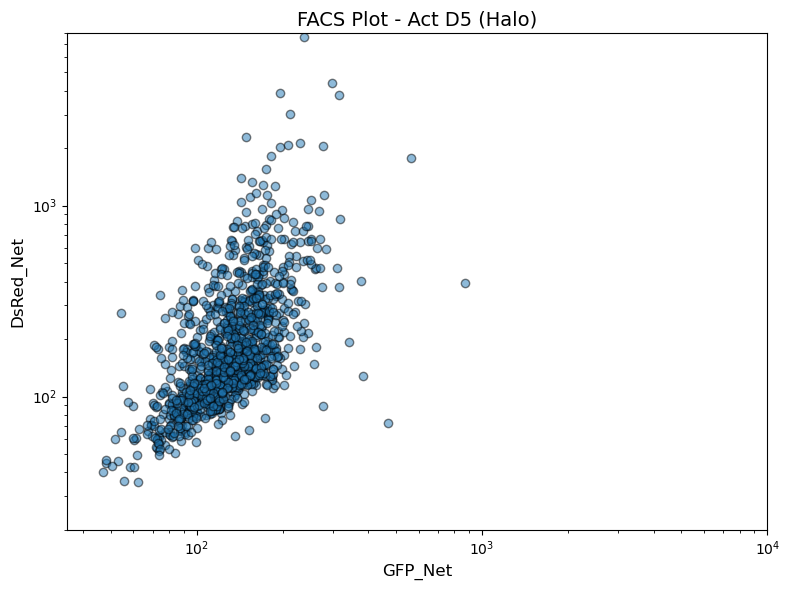

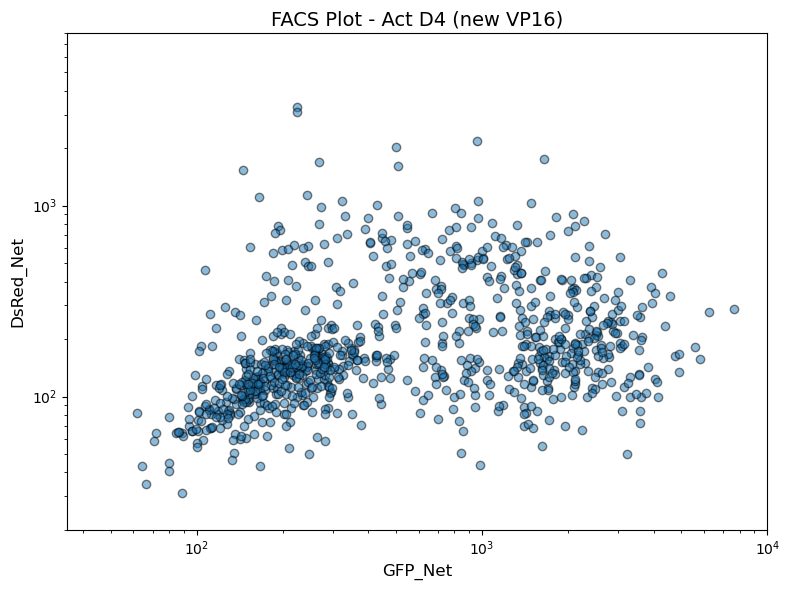

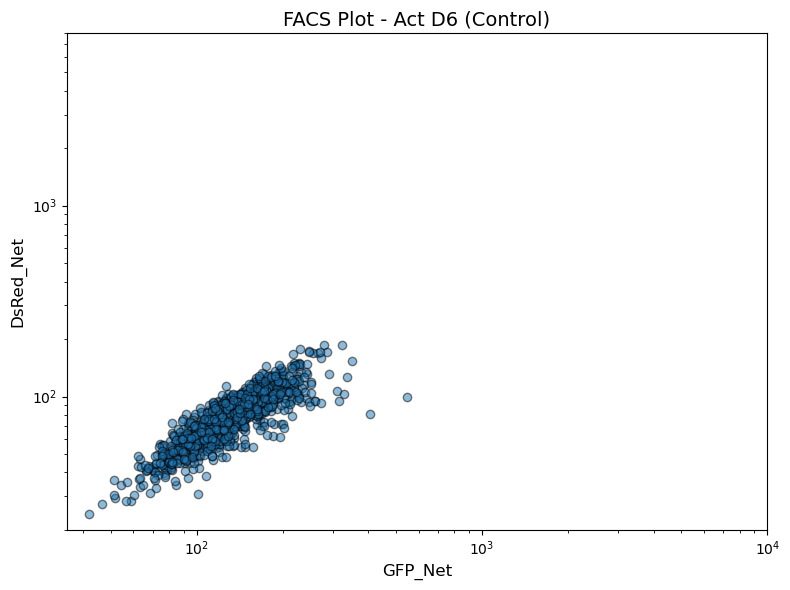

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net (log scale) and the y-axis is DsRed_Net (log scale).
    Optionally, you can pass x_range and y_range tuples to manually set the axis limits.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net", "DsRed_Net", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sample["GFP_Net"], df_sample["DsRed_Net"], alpha=0.5, edgecolor='k')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("GFP_Net", fontsize=12)
    plt.ylabel("DsRed_Net", fontsize=12)
    plt.title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Update the path below as needed.
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
df = pd.read_excel(input_excel)

# Example: Plot Act group, sample A1.
# You can specify x_range and y_range manually (e.g., (10, 8000)); here, they are left as None.
plot_facs_sample(df, group="Act", sample_code="D5", x_range=(35, 10000), y_range=(20, 8000))
plot_facs_sample(df, group="Act", sample_code="D4", x_range=(35, 10000), y_range=(20, 8000))
plot_facs_sample(df, group="Act", sample_code="D6", x_range=(35, 10000), y_range=(20, 8000))

# Later, when you want to manually set ranges, for example:
# plot_facs_sample(df, group="Act", sample_code="A1", x_range=(10, 8000), y_range=(10, 10000))


# area in consider (sum)

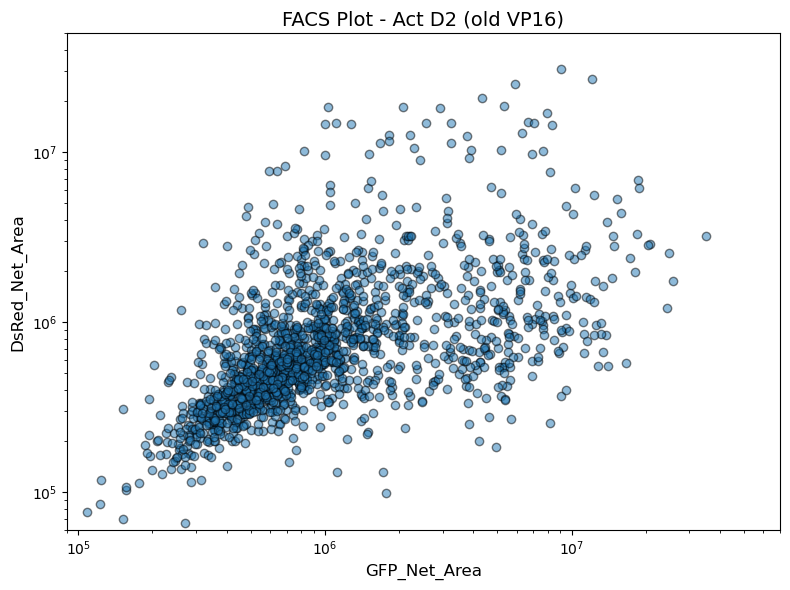

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net (log scale) and the y-axis is DsRed_Net (log scale).
    Optionally, you can pass x_range and y_range tuples to manually set the axis limits.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net", "DsRed_Net", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sample["GFP_Net_Area"], df_sample["DsRed_Net_Area"], alpha=0.5, edgecolor='k')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_Net_Area", fontsize=12)
    plt.title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Update the path below as needed.
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
df = pd.read_excel(input_excel)

# Example: Plot Act group, sample A1.
# You can specify x_range and y_range manually (e.g., (10, 8000)); here, they are left as None.
plot_facs_sample(df, group="Act", sample_code="D2", x_range=(90000, 70000000), y_range=(60000, 50000000))

# Later, when you want to manually set ranges, for example:
# plot_facs_sample(df, group="Act", sample_code="A1", x_range=(10, 8000), y_range=(10, 10000))

In [62]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots and returns a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net_Area (log scale) and the y-axis is DsRed_Net_Area (log scale).
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net_Area", "DsRed_Net_Area", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    
    Returns:
      fig: The matplotlib figure object.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return None
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_sample["GFP_Net_Area"], df_sample["DsRed_Net_Area"], alpha=0.5, edgecolor='k')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GFP_Net_Area", fontsize=12)
    ax.set_ylabel("DsRed_Net_Area", fontsize=12)
    ax.set_title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)
    
    ax.grid(False)
    fig.tight_layout()
    return fig

def save_all_facs_plots(df, save_folder, x_range=None, y_range=None):
    """
    Loops over all unique (Group, Sample) pairs in the DataFrame and saves each FACS plot as a PNG file.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing the relevant columns.
      save_folder (str): Folder path to save the plots.
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    # Get unique combinations of Group and Sample.
    unique_samples = df[['Group', 'Sample']].drop_duplicates()
    
    for index, row in unique_samples.iterrows():
        group = row["Group"]
        sample_code = row["Sample"]
        fig = plot_facs_sample(df, group, sample_code, x_range, y_range)
        if fig is not None:
            # Create a filename such as "Act_A1_facs_plot.png"
            filename = f"{group}_{sample_code}_facs_plot.png"
            save_path = os.path.join(save_folder, filename)
            fig.savefig(save_path)
            plt.close(fig)
            print(f"Saved plot to: {save_path}")

# -----------------------------
# Example Usage:
# -----------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
df = pd.read_excel(input_excel)

# Define the folder where you want to save all the FACS plots.
output_plots_folder = r"A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW"

# Optionally, set your custom x and y ranges. For example:
# x_range=(90000, 70000000) and y_range=(60000, 50000000)
# For now, we'll leave them as None so you can manually change them later.
x_range = (90000, 70000000)
y_range = (60000, 50000000)

# Save plots for all unique sample groups.
save_all_facs_plots(df, output_plots_folder, x_range, y_range)


Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A1_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A2_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A3_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A4_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A5_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_A6_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B1_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B2_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B3_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B4_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B5_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_B6_facs_plot.png
Saved plot to: A:\_Ongoing\20250329_Rep\FIgure_2\SUMRAW\Act_C1_facs_plot.png

# Compensation Model:
We assume that the observed GFP signal includes some fraction (α) of the DsRed signal and that the observed DsRed signal includes some fraction (β) of the GFP signal. Subtracting these estimated spillover contributions gives:

GFP_comp = GFP_Net_Area – α × DsRed_Net_Area

DsRed_comp = DsRed_Net_Area – β × GFP_Net_Area

Re‑estimate β by regression on your D6 controls
Instead of just taking the median ratio, do a proper least‑squares fit (through the origin, or with intercept) so that the residuals in your D6 controls are centered around zero with as little slope as possible.

In [1]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel  = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
output_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_compensated_refit.xlsx"

# -----------------------------
# READ THE DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# RE‑ESTIMATE SPILLOVER COEFFICIENTS FROM D6 CONTROLS
# -----------------------------
# We'll fit DsRed_obs = beta · GFP_obs + intercept for each group using D6 cells.
comp_params = {}
for grp in df['Group'].unique():
    ctrl = df[(df['Group']==grp) & (df['Sample']=='D6')]
    x = ctrl['GFP_Net_Area'].values
    y = ctrl['DsRed_Net_Area'].values
    # Fit a line y = beta*x + intercept
    beta, intercept = np.polyfit(x, y, 1)
    comp_params[grp] = {'beta': beta, 'intercept': intercept}

# -----------------------------
# APPLY COMPENSATION & ZERO‑CENTER CONTROL
# -----------------------------
# First subtract the fitted line, then shift so D6 median is exactly zero.
df['DsRed_comp_raw'] = df.apply(
    lambda r: r['DsRed_Net_Area']
              - comp_params[r['Group']]['beta'] * r['GFP_Net_Area']
              - comp_params[r['Group']]['intercept'],
    axis=1
)

# Compute D6 median after raw compensation:
medians = df[df['Sample']=='D6'].groupby('Group')['DsRed_comp_raw'].median().to_dict()

# Final compensated value:
df['DsRed_comp'] = df.apply(
    lambda r: r['DsRed_comp_raw'] - medians[r['Group']],
    axis=1
)

# (Optionally) drop the intermediate column:
df.drop(columns=['DsRed_comp_raw'], inplace=True)

# -----------------------------
# SAVE COMPENSATED DATA
# -----------------------------
df.to_excel(output_excel, index=False)
print("Re‑fitted compensation saved to:", output_excel)


Re‑fitted compensation saved to: A:\_Ongoing\20250329_Rep\Output\summary_compensated_refit.xlsx


# plot in lieanr scale to find the missing negtative data

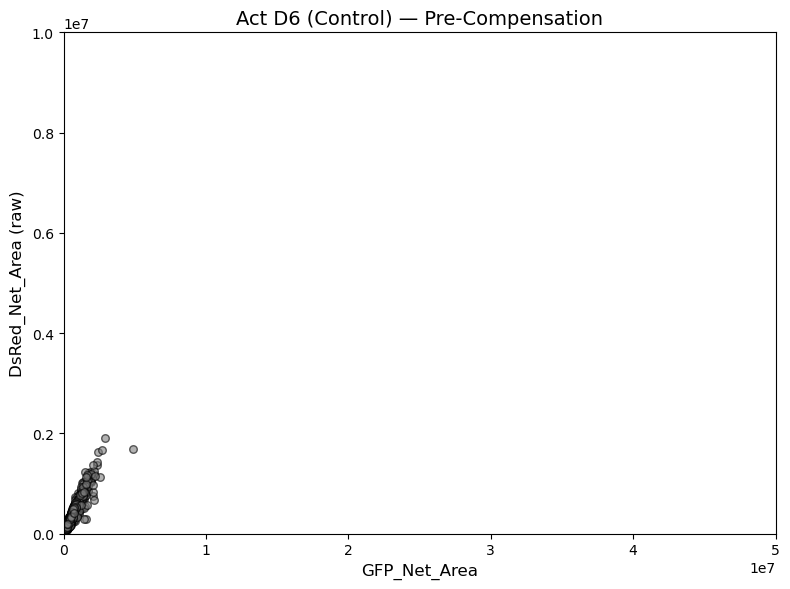

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_original_linear(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots GFP_Net_Area vs. DsRed_Net_Area (pre‑compensation) on a linear scale,
    highlighting any low‑signal points if you like.
    """
    sub = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if sub.empty:
        print(f"No data for {group} {sample_code}")
        return

    # get sample name if available
    if "Sample_name" in sub.columns and not sub["Sample_name"].isna().all():
        name = sub["Sample_name"].iloc[0]
    else:
        name = sample_code

    plt.figure(figsize=(8,6))
    plt.scatter(
        sub["GFP_Net_Area"],
        sub["DsRed_Net_Area"],
        c='gray', alpha=0.6, edgecolor='k', s=30
    )
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_Net_Area (raw)", fontsize=12)
    plt.title(f"{group} {sample_code} ({name}) — Pre‑Compensation", fontsize=14)

    if x_range:
        plt.xlim(x_range)
    if y_range:
        plt.ylim(y_range)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage
# -----------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
df_orig = pd.read_excel(input_excel)

plot_original_linear(
    df_orig,
    group="Act",
    sample_code="D6",
    x_range=(0, 5e7),
    y_range=(0, 1e7)
)


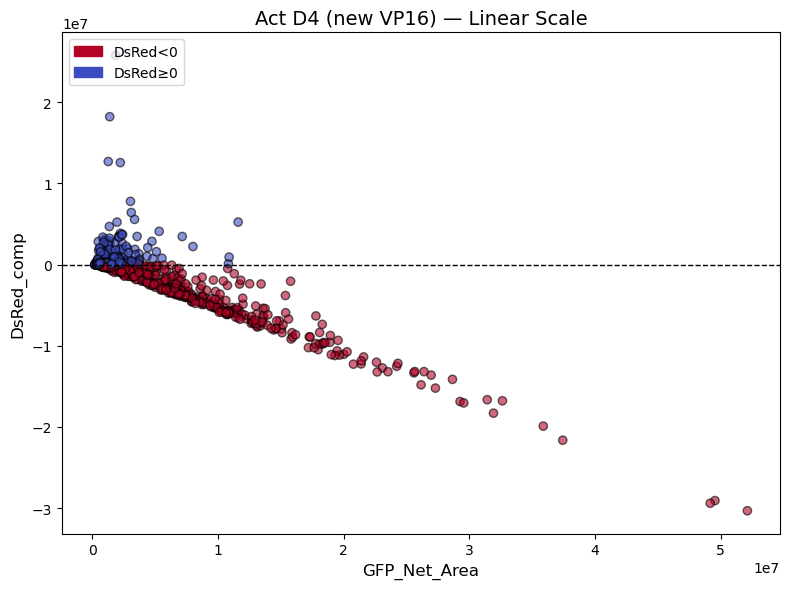

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_facs_sample_linear(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS‐like scatter plot for a specified group and sample on a linear scale,
    highlighting negative DsRed_comp values.
    """
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data for {group} {sample_code}.")
        return

    # Safely grab the first Sample_name if it exists
    if "Sample_name" in df_sample.columns and not df_sample["Sample_name"].isna().all():
        sample_name = df_sample["Sample_name"].iloc[0]
    else:
        sample_name = sample_code

    plt.figure(figsize=(8,6))
    # color negative DsRed_comp differently
    colors = df_sample["DsRed_comp"] < 0
    cmap = plt.get_cmap("coolwarm")
    plt.scatter(
        df_sample["GFP_Net_Area"],
        df_sample["DsRed_comp"],
        c=colors.map({True: cmap(1.0), False: cmap(0.0)}),
        alpha=0.6,
        edgecolor='k'
    )
    plt.axhline(0, color='black', linestyle='--', lw=1)
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_comp", fontsize=12)
    plt.title(f"{group} {sample_code} ({sample_name}) — Linear Scale", fontsize=14)

    if x_range:
        plt.xlim(x_range)
    if y_range:
        plt.ylim(y_range)

    # create a simple legend
    neg_patch = mpatches.Patch(color=cmap(1.0), label="DsRed<0")
    pos_patch = mpatches.Patch(color=cmap(0.0), label="DsRed≥0")
    plt.legend(handles=[neg_patch, pos_patch], loc="upper left")

    plt.tight_layout()
    plt.show()


# -------------------------------
# Example
# -------------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_compensated_matrix.xlsx"
df = pd.read_excel(input_excel)

plot_facs_sample_linear(df, group="Act", sample_code="D4",
                        x_range=None, y_range=None)


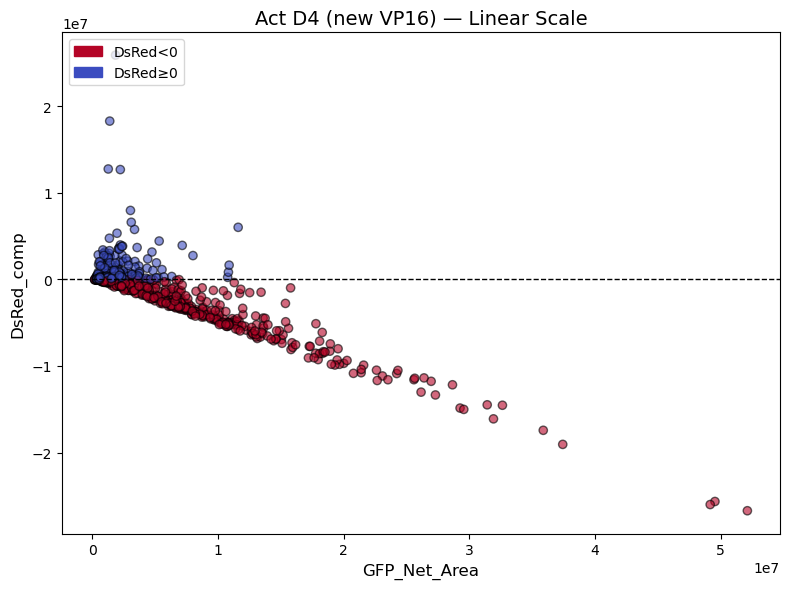

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -------------------------------
# Test after another compensate
# -------------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_compensated_refit.xlsx"

df = pd.read_excel(input_excel)

plot_facs_sample_linear(df, group="Act", sample_code="D4",
                        x_range=None, y_range=None)


# Log‑space compensation
log10 (DsRed)≈mlog10(GFP)+b


In [10]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel  = r"A:\_Ongoing\20250329_Rep\Output\summary_net_area.xlsx"
output_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_log_compensated.xlsx"

# Small constant to avoid log(0)
epsilon = 1e-10

# -----------------------------
# READ THE DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# LOG-TRANSFORM BOTH CHANNELS
# -----------------------------
df["logGFP"]   = np.log10(df["GFP_Net_Area"] + epsilon)
df["logDsRed"] = np.log10(df["DsRed_Net_Area"] + epsilon)

# -----------------------------
# FIT LINEAR MODEL IN LOG–LOG SPACE FOR EACH GROUP
# -----------------------------
comp_params = {}
for grp in df["Group"].unique():
    ctrl = df[(df["Group"] == grp) & (df["Sample"] == "D6")]
    x = ctrl["logGFP"].values
    y = ctrl["logDsRed"].values
    # Fit y ≈ m*x + b
    m, b = np.polyfit(x, y, 1)
    comp_params[grp] = {"slope": m, "intercept": b}

# -----------------------------
# APPLY LOG-SPACE COMPENSATION
# -----------------------------
# logDsRed_comp = logDsRed - (m*logGFP + b)
df["logDsRed_comp"] = df.apply(
    lambda r: r["logDsRed"]
              - (comp_params[r["Group"]]["slope"] * r["logGFP"]
                 + comp_params[r["Group"]]["intercept"]),
    axis=1
)

# -----------------------------
# OPTIONAL: BACK-TRANSFORM TO LINEAR SCALE
# -----------------------------
# You can recover a linear-scale compensated value if needed:
df["DsRed_comp_log"] = 10 ** df["logDsRed_comp"]

# -----------------------------
# SAVE THE RESULTS
# -----------------------------
df.to_excel(output_excel, index=False)
print("Log-space compensated data saved to:", output_excel)


Log-space compensated data saved to: A:\_Ongoing\20250329_Rep\Output\summary_log_compensated.xlsx


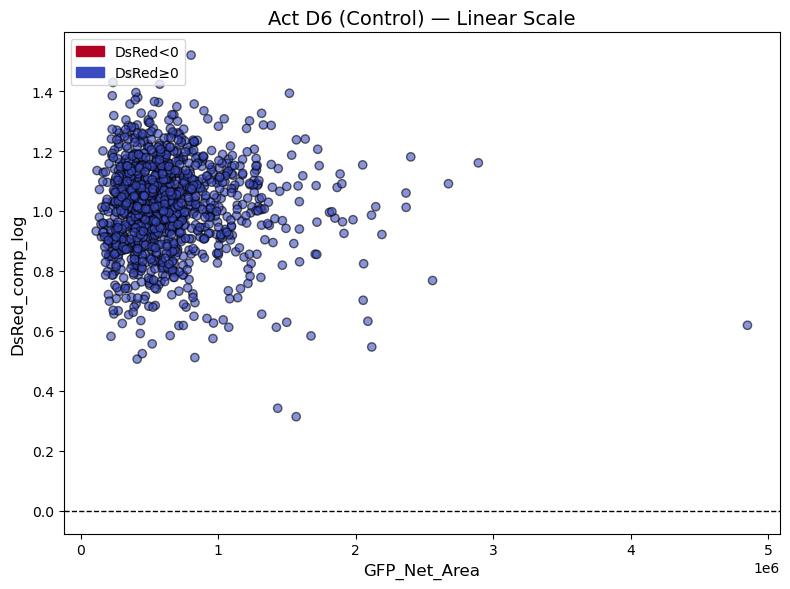

In [ ]:
# Check linear Plots

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_facs_sample_linear(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS‐like scatter plot for a specified group and sample on a linear scale,
    highlighting negative DsRed_comp values.
    """
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data for {group} {sample_code}.")
        return

    # Safely grab the first Sample_name if it exists
    if "Sample_name" in df_sample.columns and not df_sample["Sample_name"].isna().all():
        sample_name = df_sample["Sample_name"].iloc[0]
    else:
        sample_name = sample_code

    plt.figure(figsize=(8,6))
    # color negative DsRed_comp differently
    colors = df_sample["DsRed_comp_log"] < 0
    cmap = plt.get_cmap("coolwarm")
    plt.scatter(
        df_sample["GFP_Net_Area"],
        df_sample["DsRed_comp_log"],
        c=colors.map({True: cmap(1.0), False: cmap(0.0)}),
        alpha=0.6,
        edgecolor='k'
    )
    plt.axhline(0, color='black', linestyle='--', lw=1)
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_comp_log", fontsize=12)
    plt.title(f"{group} {sample_code} ({sample_name}) — Linear Scale", fontsize=14)

    if x_range:
        plt.xlim(x_range)
    if y_range:
        plt.ylim(y_range)

    # create a simple legend
    neg_patch = mpatches.Patch(color=cmap(1.0), label="DsRed<0")
    pos_patch = mpatches.Patch(color=cmap(0.0), label="DsRed≥0")
    plt.legend(handles=[neg_patch, pos_patch], loc="upper left")

    plt.tight_layout()
    plt.show()


# -------------------------------
# Example
# -------------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_log_compensated.xlsx"
df = pd.read_excel(input_excel)

plot_facs_sample_linear(df, group="Act", sample_code="D6",
                        x_range=None, y_range=None)

C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_24140\834601838.py:42: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(x_range)
C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_24140\834601838.py:44: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(y_range)


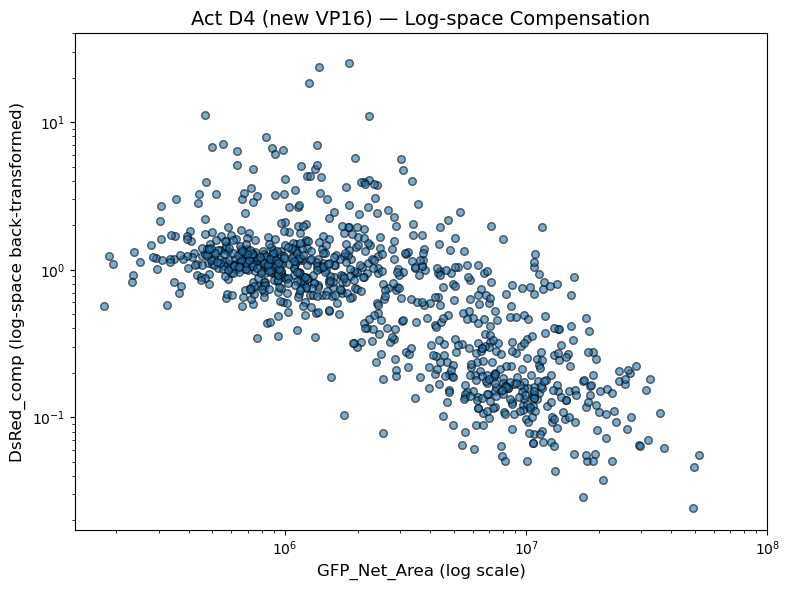

In [ ]:
# Check Log scale Plots

import pandas as pd
import matplotlib.pyplot as plt

def plot_log_compensation(df, group, sample_code, x_range=None, y_range=None):
    """
    Scatter‐plot GFP_Net_Area vs. DsRed_comp_log (back‐transformed from log‐space compensation)
    on log–log axes so you can see how the log‐space compensation performed.

    Parameters:
      df (DataFrame): Must contain columns "Group", "Sample", "GFP_Net_Area", "DsRed_comp_log", "Sample_name" (optional)
      group (str): e.g. "Act" or "Rep"
      sample_code (str): e.g. "A1", "D4"
      x_range (tuple, optional): (xmin, xmax) on the GFP axis
      y_range (tuple, optional): (ymin, ymax) on the DsRed axis
    """
    sub = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if sub.empty:
        print(f"No data for {group} {sample_code}")
        return

    # Sample name fallback
    if "Sample_name" in sub.columns and not sub["Sample_name"].isna().all():
        name = sub["Sample_name"].iloc[0]
    else:
        name = sample_code

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        sub["GFP_Net_Area"],
        sub["DsRed_comp_log"],
        alpha=0.6,
        edgecolor="k",
        s=30
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GFP_Net_Area (log scale)", fontsize=12)
    ax.set_ylabel("DsRed_comp (log‐space back-transformed)", fontsize=12)
    ax.set_title(f"{group} {sample_code} ({name}) — Log‐space Compensation", fontsize=14)

    if x_range:
        ax.set_xlim(x_range)
    if y_range:
        ax.set_ylim(y_range)

    ax.grid(False)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example Usage
# -----------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_log_compensated.xlsx"
df = pd.read_excel(input_excel)

plot_log_compensation(
    df,
    group="Act",
    sample_code="D4",
    x_range=(0,1e8),
    y_range=(0,40)
)


In [37]:
# Save all Plots
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_log_compensation(df, group, sample_code, x_range=None, y_range=None):
    """
    Creates and returns a scatter‐plot of GFP_Net_Area vs. DsRed_comp_log
    on log–log axes for a specified group and sample.
    """
    sub = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if sub.empty:
        return None

    # Sample name fallback
    if "Sample_name" in sub.columns and not sub["Sample_name"].isna().all():
        name = sub["Sample_name"].iloc[0]
    else:
        name = sample_code

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        sub["GFP_Net_Area"],
        sub["DsRed_comp_log"],
        alpha=0.6,
        edgecolor="k",
        s=30
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GFP_Net_Area (log scale)", fontsize=12)
    ax.set_ylabel("DsRed_comp (log‐space back-transformed)", fontsize=12)
    ax.set_title(f"{group} {sample_code} ({name}) — Log‐space Compensation", fontsize=14)

    if x_range:
        ax.set_xlim(x_range)
    if y_range:
        ax.set_ylim(y_range)

    ax.grid(False)
    plt.tight_layout()
    return fig

def save_all_log_plots(input_excel, output_folder, x_range=None, y_range=None):
    """
    Loads the compensated DataFrame, then for every unique (Group, Sample),
    generates the log-space compensation plot and saves it as a PNG.
    """
    df = pd.read_excel(input_excel)
    os.makedirs(output_folder, exist_ok=True)

    unique_pairs = df[["Group", "Sample"]].drop_duplicates()
    for _, row in unique_pairs.iterrows():
        group = row["Group"]
        sample = row["Sample"]
        fig = plot_log_compensation(df, group, sample, x_range, y_range)
        if fig is not None:
            fname = f"{group}_{sample}_log_comp.png"
            path = os.path.join(output_folder, fname)
            fig.savefig(path)
            plt.close(fig)
            print(f"Saved: {path}")

# -----------------------------
# Usage
# -----------------------------
input_excel    = r"A:\_Ongoing\20250329_Rep\Output\summary_log_compensated.xlsx"
output_folder  = r"A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots"
x_limits = (5e4, 1e8)
y_limits = (2e-2, 130)  

save_all_log_plots(input_excel, output_folder, x_limits, y_limits)


Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A1_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A2_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A3_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A4_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A5_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_A6_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B1_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B2_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B3_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B4_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B5_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_B6_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output\Log_Comp_Plots\Act_C1_log_comp.png
Saved: A:\_Ongoing\20250329_Rep\Output

# base on Blank sample, filter out untransfected cell and calculate the positive ratio

In [3]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_compensated_matrix.xlsx"  
output_excel_cells = r"A:\_Ongoing\20250329_Rep\Output\summary_cells_with_flags.xlsx"
output_excel_summary = r"A:\_Ongoing\20250329_Rep\Output\summary_thresholds_and_ratio.xlsx"

# -----------------------------
# READ THE DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# CALCULATE THRESHOLDS FROM CONTROL (D6)
# -----------------------------
# For each group, use only D6 control cells.
# Use only the positive values (GFP_comp > 0 and DsRed_comp > 0) to calculate the 99.5th percentile.
thresholds = {}
for group in df["Group"].unique():
    ctrl = df[(df["Group"] == group) & (df["Sample"] == "D6")]
    pos_gfp = ctrl[ctrl["GFP_comp"] > 0]["GFP_comp"]
    pos_dsred = ctrl[ctrl["DsRed_comp"] > 0]["DsRed_comp"]
    th_gfp = np.percentile(pos_gfp, 99.5) if not pos_gfp.empty else np.nan
    th_dsred = np.percentile(pos_dsred, 99.5) if not pos_dsred.empty else np.nan
    thresholds[group] = {"GFP": th_gfp, "DsRed": th_dsred}

print("Calculated thresholds (99.5th percentile on positive cells) per group from D6 control:")
print(thresholds)

# -----------------------------
# ASSIGN POSITIVITY FLAGS AT THE CELL LEVEL
# -----------------------------
def mark_positive(row):
    group = row["Group"]
    th_gfp = thresholds[group]["GFP"]
    th_dsred = thresholds[group]["DsRed"]
    pos_gfp = False
    pos_dsred = False
    if not np.isnan(th_gfp):
        pos_gfp = row["GFP_comp"] > th_gfp
    if not np.isnan(th_dsred):
        pos_dsred = row["DsRed_comp"] > th_dsred
    return pd.Series({"GFP_Positive": pos_gfp, "DsRed_Positive": pos_dsred})

df[["GFP_Positive", "DsRed_Positive"]] = df.apply(mark_positive, axis=1)

# Also, record the percentage of negative cells in each sample (i.e. cells with non-positive values).
# We'll build a sample-level summary.
summary_list = []
unique_samples = df[['Group', 'Sample']].drop_duplicates()

for _, row in unique_samples.iterrows():
    group = row["Group"]
    sample = row["Sample"]
    sample_df = df[(df["Group"] == group) & (df["Sample"] == sample)]
    total = len(sample_df)
    neg_gfp = np.sum(sample_df["GFP_comp"] <= 0)
    neg_dsred = np.sum(sample_df["DsRed_comp"] <= 0)
    pct_neg_gfp = (neg_gfp / total) * 100 if total > 0 else np.nan
    pct_neg_dsred = (neg_dsred / total) * 100 if total > 0 else np.nan
    
    # Calculate the ratio: (# cells positive for both GFP and DsRed) / (# cells positive for DsRed)
    pos_dsred = sample_df["DsRed_Positive"].sum()
    pos_both = ((sample_df["GFP_Positive"]) & (sample_df["DsRed_Positive"])).sum()
    ratio = pos_both / pos_dsred if pos_dsred > 0 else np.nan
    
    summary_list.append({
        "Group": group,
        "Sample": sample,
        "Total_Cells": total,
        "Negative_GFP_%": pct_neg_gfp,
        "Negative_DsRed_%": pct_neg_dsred,
        "DsRed_Positive_Cells": pos_dsred,
        "Both_Positive_Cells": pos_both,
        "Ratio_Both_over_DsRed": ratio
    })

df_summary = pd.DataFrame(summary_list)

# -----------------------------
# SAVE THE OUTPUTS TO EXCEL
# -----------------------------
df.to_excel(output_excel_cells, index=False)
print("Cell-level data with positivity flags saved to:", output_excel_cells)

df_summary.to_excel(output_excel_summary, index=False)
print("Summary (thresholds, negative percentages, ratio) saved to:", output_excel_summary)


Calculated thresholds (99.5th percentile on positive cells) per group from D6 control:
{'Act': {'GFP': np.float64(2340094.050000003), 'DsRed': np.float64(187913.39928868823)}, 'Rep': {'GFP': np.float64(29654755.03500008), 'DsRed': np.float64(347670.1310960622)}}
Cell-level data with positivity flags saved to: A:\_Ongoing\20250329_Rep\Output\summary_cells_with_flags.xlsx
Summary (thresholds, negative percentages, ratio) saved to: A:\_Ongoing\20250329_Rep\Output\summary_thresholds_and_ratio.xlsx


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def assign_cell_color(row):
    """
    Assign a color based on the positivity flags.
      - Both negative -> "gray"
      - Only DsRed positive -> "red"
      - Only GFP positive -> "green"
      - Both positive -> "purple"
    """
    if (not row["GFP_Positive"]) and (not row["DsRed_Positive"]):
        return "gray"
    elif (not row["GFP_Positive"]) and (row["DsRed_Positive"]):
        return "red"
    elif (row["GFP_Positive"]) and (not row["DsRed_Positive"]):
        return "green"
    elif (row["GFP_Positive"]) and (row["DsRed_Positive"]):
        return "purple"
    else:
        return "black"  # fallback

def plot_sample_with_threshold(df, group, sample_code, threshold_gfp, threshold_dsred, 
                               x_range=None, y_range=None):
    """
    Creates a FACS-style scatter plot for a specific sample from the cell-level summary.
    
    Axes:
      - x-axis: GFP_comp (log scale)
      - y-axis: DsRed_comp (log scale)
      
    Overlays:
      - Vertical line at threshold_gfp
      - Horizontal line at threshold_dsred
      
    Colors:
      - Grey: both negative
      - Red: DsRed positive only
      - Green: GFP positive only
      - Purple: both positive
      
    Also calculates the ratio: (# cells positive for both) / (# cells positive for DsRed) * 100,
    and displays that ratio (in percentage) in the top-right corner of the plot (without any label text).
    
    Parameters:
      df (DataFrame): The summary cell-level DataFrame. It must include the columns:
                      "Group", "Sample", "GFP_comp", "DsRed_comp", "GFP_Positive", "DsRed_Positive",
                      and "Sample_name".
      group (str): Group name (e.g., "Act" or "Rep").
      sample_code (str): Sample code (e.g., "A1").
      threshold_gfp (float): The GFP threshold (vertical line) to draw.
      threshold_dsred (float): The DsRed threshold (horizontal line) to draw.
      x_range (tuple, optional): (xmin, xmax) for the x-axis.
      y_range (tuple, optional): (ymin, ymax) for the y-axis.
      
    Returns:
      fig: The created matplotlib Figure object.
    """
    # Filter data for the specified sample.
    sample_df = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if sample_df.empty:
        print(f"No data found for {group} {sample_code}.")
        return None
    
    # Retrieve sample descriptive name if available.
    sample_name = sample_df["Sample_name"].iloc[0] if "Sample_name" in sample_df.columns else sample_code
    
    # Assign color based on positivity.
    sample_df = sample_df.copy()  # avoid modifying original DataFrame
    sample_df["Color"] = sample_df.apply(assign_cell_color, axis=1)
    
    # Calculate the ratio: (# cells positive for both) / (# cells positive for DsRed) * 100.
    num_pos_dsred = sample_df["DsRed_Positive"].sum()
    num_both = ((sample_df["GFP_Positive"]) & (sample_df["DsRed_Positive"])).sum()
    ratio = (num_both / num_pos_dsred * 100) if num_pos_dsred > 0 else np.nan
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create scatter plot.
    scatter = ax.scatter(sample_df["GFP_comp"], sample_df["DsRed_comp"], 
                         c=sample_df["Color"], alpha=0.6, edgecolor="k", s=40)
    
    # Set log scale.
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # Set axis limits if provided.
    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)
    
    ax.set_xlabel("GFP_comp", fontsize=12)
    ax.set_ylabel("DsRed_comp", fontsize=12)
    ax.set_title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Draw threshold lines:
    ax.axvline(threshold_gfp, color="black", linestyle="--", linewidth=1)
    ax.axhline(threshold_dsred, color="black", linestyle="--", linewidth=1)
    
    # Place the ratio in the top-right corner using axis coordinates.
    if not np.isnan(ratio):
        ax.text(0.98, 0.98, f"{ratio:.1f}%", transform=ax.transAxes, 
                horizontalalignment="right", verticalalignment="top", fontsize=12)
    
    ax.grid(False)
    plt.tight_layout()
    
    return fig

def save_all_sample_plots(df, save_folder, threshold_dict, x_range=None, y_range=None):
    """
    Loops through all unique (Group, Sample) pairs in df and saves each FACS-style plot as a PNG.
    
    Parameters:
      df (DataFrame): The cell-level summary DataFrame.
      save_folder (str): Directory in which to save the plots.
      threshold_dict (dict): A dictionary with group keys containing a dictionary with keys 
                             "GFP" and "DsRed" for the threshold values.
                             For example: {"Act": {"GFP": val1, "DsRed": val2}, ...}
      x_range (tuple, optional): x-axis limits.
      y_range (tuple, optional): y-axis limits.
    """
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    unique_samples = df[['Group', 'Sample']].drop_duplicates()
    for _, row in unique_samples.iterrows():
        group = row["Group"]
        sample = row["Sample"]
        thresh_gfp = threshold_dict.get(group, {}).get("GFP", None)
        thresh_dsred = threshold_dict.get(group, {}).get("DsRed", None)
        fig = plot_sample_with_threshold(df, group, sample, thresh_gfp, thresh_dsred, x_range, y_range)
        if fig is not None:
            filename = f"{group}_{sample}_facs.png"
            filepath = os.path.join(save_folder, filename)
            fig.savefig(filepath)
            plt.close(fig)
            print(f"Saved plot: {filepath}")

# -----------------------------
# Example Usage:
# -----------------------------
# Load the cell-level data that includes positivity flags.
input_cells_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_cells_with_flags.xlsx"
df_cells = pd.read_excel(input_cells_excel)

# Define thresholds (these should be determined from your D6 control in each group, 
# using the 99.5th percentile on the positive values, for example).
# For this example, we'll provide some dummy numbers; adjust them as needed.
# For instance, assume for group Act: GFP threshold = 20000, DsRed threshold = 15000
# and for group Rep: GFP threshold = 50000, DsRed threshold = 40000.
thresholds = {
    "Act": {"GFP": 2340094.050000003, "DsRed": 187913.39928868823},
    "Rep": {"GFP": 29654755.03500008, "DsRed": 347670.1310960622}
}

# Optionally, you can set custom x_range and y_range (on log scale) for the plots.
x_limits = (50000, 70000000)
y_limits = (1000, 50000000)

# Define folder to save the plots.
output_plots_folder = r"A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots"

# Save plots for all unique samples.
save_all_sample_plots(df_cells, output_plots_folder, thresholds, x_range=x_limits, y_range=y_limits)


Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A1_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A2_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A3_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A4_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A5_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_A6_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B1_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B2_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B3_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B4_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B5_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Act_B6_facs.png
Saved plot: A:\_Ongoing\20250329_Rep\FIgure_2\FACS_flag_plots\Ac

# only consider DsRed Positive and make box plots

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Sample mapping dictionary (should be defined as in your data)
sample_mapping = {
    "A1": "Tile 1",
    "A2": "Tile 2",
    "A3": "Tile 3",
    "A4": "Tile 4",
    "A5": "Tile 5",
    "A6": "Tile 6",
    "B1": "Tile 7",
    "B2": "Tile 8",
    "B3": "Tile 9",
    "B4": "Tile 10",
    "B5": "Tile 11",
    "B6": "Tile 12",
    "C1": "Tile 13",
    "C2": "Tile 14",
    "C3": "LAP*IDR",
    "C4": "LAPIDR",
    "C5": "LIPIDR",
    "C6": "FL",
    "D1": "optLAP*IDR",
    "D2": "old VP16",
    "D3": "old RUNX2CTD",
    "D4": "new VP16",
    "D5": "Halo",
    "D6": "Control"
}

def natural_sort_key(s):
    """
    Returns a tuple for natural sorting of strings like 'A1', 'A2', 'D5'.
    """
    m = re.match(r"([A-Za-z]+)(\d+)", s)
    if m:
        return (m.group(1), int(m.group(2)))
    else:
        return (s, 0)

def create_boxplot_for_group(df, group, x_limits, save_path):
    """
    Creates and saves a vertical (stacked) box plot for one group (e.g., "Act" or "Rep").
    
    The data are filtered to only include DsRed positive cells. The plot uses "GFP_comp" on the 
    x-axis (log scale) and shows a box plot for each sample (ordered naturally by the sample code), 
    with the y-tick labels replaced by the descriptive names from sample_mapping.
    
    Parameters:
      df (DataFrame): The cell-level data, which must contain the following columns:
                      "Group", "Sample", "GFP_comp", "DsRed_comp", "DsRed_Positive", and "Sample_name" (optional)
      group (str): The group to plot (e.g., "Act" or "Rep").
      x_limits (tuple): (xmin, xmax) for the x-axis in the box plot.
      save_path (str): The file path (including filename) to save the plot.
    """
    # Filter to the specified group and only DsRed positive cells.
    df_group = df[(df["Group"] == group) & (df["DsRed_Positive"] == True)]
    
    if df_group.empty:
        print(f"No data for group {group} with DsRed positive cells.")
        return

    # Determine the unique sample codes in natural order.
    sample_codes = sorted(df_group["Sample"].unique(), key=natural_sort_key)
    
    # Create a new column for the sample labels based on sample_mapping.
    # If the "Sample_name" column exists and is valid, you can use that. Otherwise, map using sample_mapping.
    df_group["Sample_Label"] = df_group["Sample"].map(lambda s: sample_mapping.get(s, s))
    
    # Create the box plot. We'll plot GFP_comp (x-axis) vs. Sample (y-axis, categorical)
    fig, ax = plt.subplots(figsize=(8, len(sample_codes) * 0.6 + 2))
    
    # Use seaborn's boxplot; set order by sample code so they stack in order.
    sns.boxplot(x="GFP_comp", y="Sample", data=df_group, order=sample_codes, ax=ax,
                orient="h", color="skyblue", fliersize=3)
    
    # Set x-axis to log scale.
    ax.set_xscale("log")
    ax.set_xlim(x_limits)
    
    ax.set_xlabel("GFP_comp (log scale)", fontsize=12)
    ax.set_ylabel("")  # We'll replace y labels
    
    # Replace y-axis tick labels with descriptive names.
    # The ticks are in the same order as sample_codes.
    new_labels = [sample_mapping.get(s, s) for s in sample_codes]
    ax.set_yticklabels(new_labels, fontsize=10)
    
    ax.set_title(f"Box Plot of GFP_comp (DsRed Positive) - {group} Group", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)
    print(f"Saved box plot for group {group} to {save_path}")

# -----------------------------
# Main Code to Loop Over Groups and Save Plots
# -----------------------------
input_cells_excel = r"A:\_Ongoing\20250329_Rep\Output\summary_cells_with_flags.xlsx"
df_cells = pd.read_excel(input_cells_excel)

# Set the x-axis limits for the box plot as provided.
x_limits = (50000, 70000000)

# Define the output folder for the plots.
output_folder = r"a:\_Ongoing\20250329_Rep\FIgure_2"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# For each group of interest (e.g. Act and Rep), create and save the plot.
for grp in df_cells["Group"].unique():
    save_path = os.path.join(output_folder, f"{grp}_GFP_comp_BoxPlot.png")
    create_boxplot_for_group(df_cells, grp, x_limits, save_path)


C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_35944\3463150588.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["Sample_Label"] = df_group["Sample"].map(lambda s: sample_mapping.get(s, s))
C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_35944\3463150588.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels, fontsize=10)


Saved box plot for group Act to a:\_Ongoing\20250329_Rep\FIgure_2\Act_GFP_comp_BoxPlot.png


C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_35944\3463150588.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["Sample_Label"] = df_group["Sample"].map(lambda s: sample_mapping.get(s, s))
C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_35944\3463150588.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels, fontsize=10)


Saved box plot for group Rep to a:\_Ongoing\20250329_Rep\FIgure_2\Rep_GFP_comp_BoxPlot.png
